In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df = pd.read_csv("traffic_volume.csv")

df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,275.51,0.03,0.10,46,Snow,shower snow,03-01-2018 05:00:00,648
1,267.91,0.10,0.41,71,Clouds,scattered clouds,04-01-2018 02:00:00,838
2,264.98,0.12,0.17,72,Clouds,overcast clouds,10-01-2018 05:00:00,494
3,269.04,0.05,0.40,50,Snow,shower snow,12-01-2018 18:00:00,2832
4,269.29,0.05,0.12,44,Snow,heavy snow,18-01-2018 17:00:00,4482


In [114]:
df.shape

(500, 8)

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp                 500 non-null    float64
 1   rain_1h              500 non-null    float64
 2   snow_1h              500 non-null    float64
 3   clouds_all           500 non-null    int64  
 4   weather_main         500 non-null    str    
 5   weather_description  500 non-null    str    
 6   date_time            500 non-null    str    
 7   traffic_volume       500 non-null    int64  
dtypes: float64(3), int64(2), str(3)
memory usage: 48.6 KB


In [116]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,281.995140,0.552240,0.150860,58.868000,2682.85200
std,12.700232,0.512065,0.143282,24.890916,1645.84752
min,258.830000,0.010000,0.010000,15.000000,192.00000
25%,271.962500,0.110000,0.050000,36.000000,856.00000
50%,280.605000,0.325000,0.090000,62.000000,2778.00000
75%,292.805000,0.980000,0.212500,80.000000,3959.75000
max,310.130000,1.640000,0.550000,99.000000,6362.00000


In [117]:
df.isnull().sum()

temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

In [118]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [119]:
df["date_time"] = pd.to_datetime(df["date_time"],format="%d-%m-%Y %H:%M:%S")
df["year"] = df["date_time"].dt.year
df["month"] = df["date_time"].dt.month
df["day"] = df["date_time"].dt.day
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek

In [120]:
df.head()   

,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,year,month,day,hour,day_of_week
0,275.51,0.03,0.10,46,Snow,shower snow,2018-01-03 05:00:00,648,2018,1,3,5,2
1,267.91,0.10,0.41,71,Clouds,scattered clouds,2018-01-04 02:00:00,838,2018,1,4,2,3
2,264.98,0.12,0.17,72,Clouds,overcast clouds,2018-01-10 05:00:00,494,2018,1,10,5,2
3,269.04,0.05,0.40,50,Snow,shower snow,2018-01-12 18:00:00,2832,2018,1,12,18,4
4,269.29,0.05,0.12,44,Snow,heavy snow,2018-01-18 17:00:00,4482,2018,1,18,17,3


In [121]:
df["is_weekend"] = df["day_of_week"].apply(
    lambda x: 1 if x >= 5 else 0
)

In [122]:
df[["date_time","year","month","day","hour", "day_of_week", "is_weekend"]].head(10)

,date_time,year,month,day,hour,day_of_week,is_weekend
0,2018-01-03 05:00:00,2018,1,3,5,2,0
1,2018-01-04 02:00:00,2018,1,4,2,3,0
2,2018-01-10 05:00:00,2018,1,10,5,2,0
3,2018-01-12 18:00:00,2018,1,12,18,4,0
4,2018-01-18 17:00:00,2018,1,18,17,3,0
5,2018-01-20 08:00:00,2018,1,20,8,5,1
6,2018-01-31 06:00:00,2018,1,31,6,2,0
7,2018-02-05 11:00:00,2018,2,5,11,0,0
8,2018-02-09 06:00:00,2018,2,9,6,4,0
9,2018-02-12 17:00:00,2018,2,12,17,0,0


In [123]:
df = df.drop("date_time", axis=1)

In [124]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,hour,day_of_week,is_weekend
0,275.51,0.03,0.10,46,Snow,shower snow,648,2018,1,3,5,2,0
1,267.91,0.10,0.41,71,Clouds,scattered clouds,838,2018,1,4,2,3,0
2,264.98,0.12,0.17,72,Clouds,overcast clouds,494,2018,1,10,5,2,0
3,269.04,0.05,0.40,50,Snow,shower snow,2832,2018,1,12,18,4,0
4,269.29,0.05,0.12,44,Snow,heavy snow,4482,2018,1,18,17,3,0


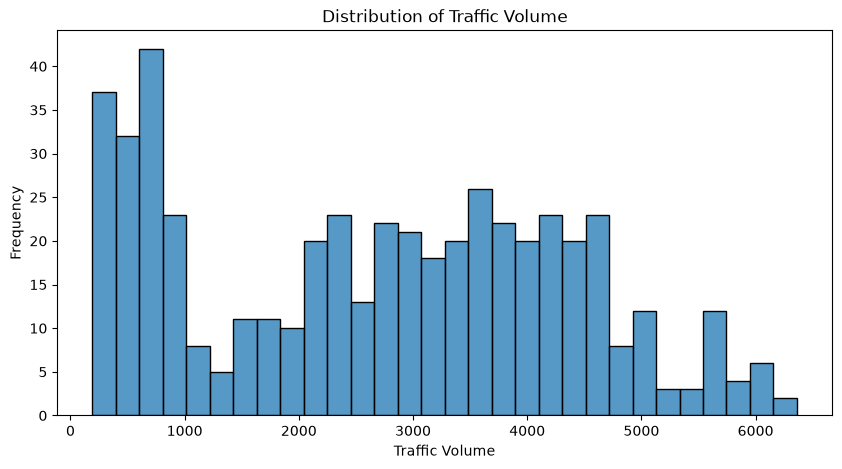

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(df["traffic_volume"], bins=30)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.show()

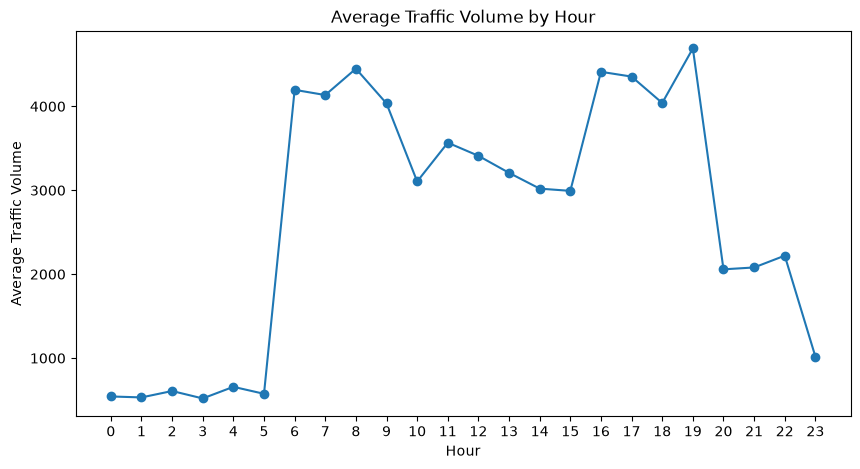

In [126]:
hourly_traffic = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10,5))

plt.plot(hourly_traffic.index, hourly_traffic.values, marker="o")

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Traffic Volume")

plt.xticks(range(0,24))

plt.show()

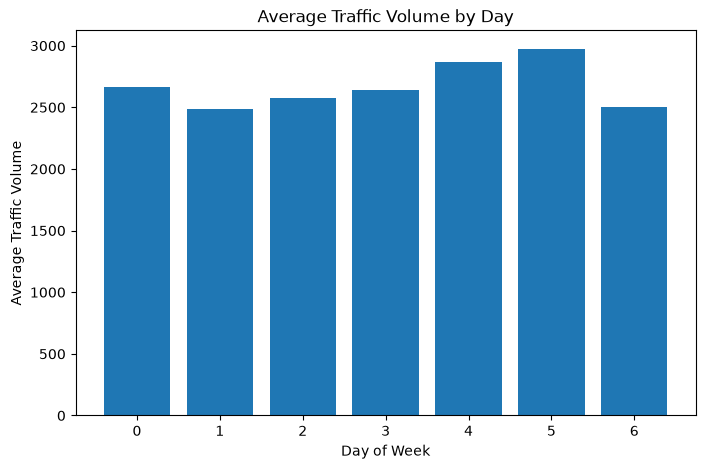

In [127]:
daily_traffic = df.groupby("day_of_week")["traffic_volume"].mean()

plt.figure(figsize=(8,5))

plt.bar(daily_traffic.index, daily_traffic.values)

plt.title("Average Traffic Volume by Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Traffic Volume")

plt.show()

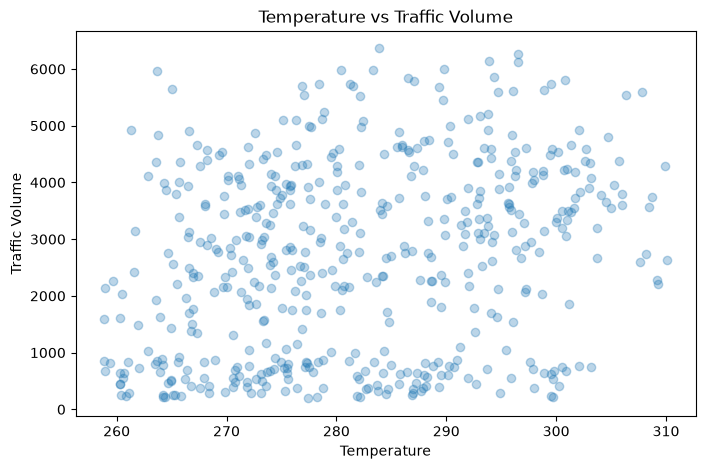

In [128]:
plt.figure(figsize=(8,5))

plt.scatter(df["temp"], df["traffic_volume"], alpha=0.3)

plt.title("Temperature vs Traffic Volume")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")

plt.show()

In [129]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

correlation

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,year,month,day,hour,day_of_week,is_weekend
temp,1.000000,0.544048,-0.631439,0.010173,0.262961,0.018128,0.117254,-0.037855,0.040865,-0.060017,-0.036263
rain_1h,0.544048,1.000000,-0.544861,-0.023734,-0.013794,0.026072,0.107935,0.023937,0.054318,-0.019000,0.010723
snow_1h,-0.631439,-0.544861,1.000000,0.035011,-0.191816,-0.041506,-0.108674,0.005476,-0.017749,0.045420,0.006171
clouds_all,0.010173,-0.023734,0.035011,1.000000,-0.017023,0.005192,-0.029409,-0.000761,0.034750,-0.012754,-0.010258
traffic_volume,0.262961,-0.013794,-0.191816,-0.017023,1.000000,-0.093306,0.006266,-0.012186,0.426146,0.040791,0.032642
year,0.018128,0.026072,-0.041506,0.005192,-0.093306,1.000000,-0.102103,0.024920,-0.031601,0.055614,0.039108
month,0.117254,0.107935,-0.108674,-0.029409,0.006266,-0.102103,1.000000,0.003781,0.011398,-0.033134,-0.026679
day,-0.037855,0.023937,0.005476,-0.000761,-0.012186,0.024920,0.003781,1.000000,0.030221,0.020522,0.025983
hour,0.040865,0.054318,-0.017749,0.034750,0.426146,-0.031601,0.011398,0.030221,1.000000,0.075455,0.043761
day_of_week,-0.060017,-0.019000,0.045420,-0.012754,0.040791,0.055614,-0.033134,0.020522,0.075455,1.000000,0.779643


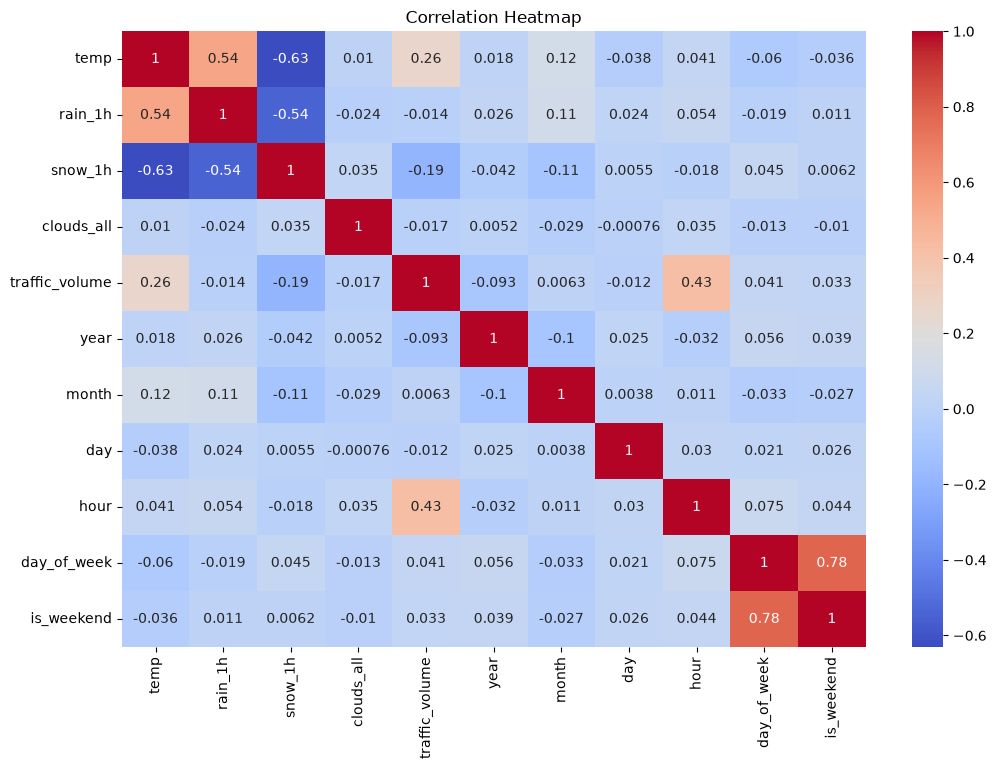

In [130]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [131]:
df = pd.get_dummies(
    df,
    columns=[
        "weather_main",
        "weather_description"
    ],
    dtype=int
)

In [132]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,year,month,day,hour,day_of_week,...,weather_description_light snow,weather_description_mist,weather_description_moderate rain,weather_description_overcast clouds,weather_description_scattered clouds,weather_description_shower snow,weather_description_sky is clear,weather_description_sleet,weather_description_snow,weather_description_very heavy rain
0,275.51,0.03,0.10,46,648,2018,1,3,5,2,...,0,0,0,0,0,1,0,0,0,0
1,267.91,0.10,0.41,71,838,2018,1,4,2,3,...,0,0,0,0,1,0,0,0,0,0
2,264.98,0.12,0.17,72,494,2018,1,10,5,2,...,0,0,0,1,0,0,0,0,0,0
3,269.04,0.05,0.40,50,2832,2018,1,12,18,4,...,0,0,0,0,0,1,0,0,0,0
4,269.29,0.05,0.12,44,4482,2018,1,18,17,3,...,0,0,0,0,0,0,0,0,0,0


In [133]:
X = df.drop("traffic_volume", axis=1)

y = df["traffic_volume"]

In [134]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 33)
y shape: (500,)


In [135]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [136]:
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit( X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

In [137]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test,y_pred_lr ))

print("Linear Regression")
print("R2 Score:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Linear Regression
R2 Score: 0.2083714567488465
MAE: 1203.6373521169673
RMSE: 1433.7605815617762


In [138]:

from sklearn.tree import DecisionTreeRegressor
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit( X_train,y_train)
y_pred_dt = model_dt.predict(X_test)

In [139]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error( y_test,y_pred_dt ))

print("Decision Tree")
print("R2 Score:", r2_dt)
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

Decision Tree
R2 Score: 0.7299632402024894
MAE: 641.2
RMSE: 837.3892046115714


In [140]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
model_rf.fit( X_train,y_train)
y_pred_rf = model_rf.predict(X_test)

In [141]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

r2_rf = r2_score(y_test, y_pred_rf)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error( y_test,y_pred_rf))

print("Random Forest")
print("R2 Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
R2 Score: 0.871797626877612
MAE: 455.81729999999993
RMSE: 576.9842334475007


In [142]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree", "Random Forest"],
    "R2 Score": [r2_lr,r2_dt, r2_rf],
    "MAE": [mae_lr,mae_dt,mae_rf],
    "RMSE": [rmse_lr,rmse_dt,rmse_rf]})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.208371,1203.637352,1433.760582
1,Decision Tree,0.729963,641.200000,837.389205
2,Random Forest,0.871798,455.817300,576.984233


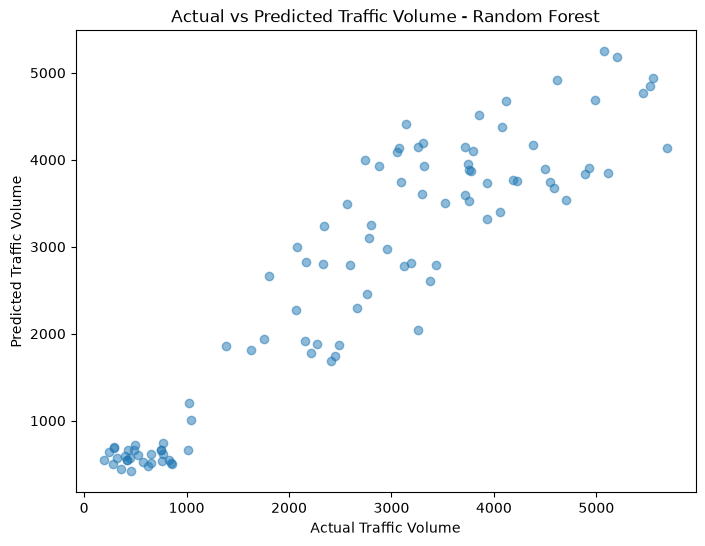

In [143]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf,alpha=0.5)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")

plt.title("Actual vs Predicted Traffic Volume - Random Forest")

plt.show()

In [144]:
feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": model_rf.feature_importances_})
feature_importance = feature_importance.sort_values( by="Importance",ascending=False)
feature_importance

,Feature,Importance
7,hour,0.831228
1,rain_1h,0.053687
0,temp,0.027364
2,snow_1h,0.018929
6,day,0.012455
4,year,0.011002
3,clouds_all,0.010596
14,weather_main_Snow,0.008714
5,month,0.006114
8,day_of_week,0.005845


In [145]:
feature_importance.head(10)

,Feature,Importance
7,hour,0.831228
1,rain_1h,0.053687
0,temp,0.027364
2,snow_1h,0.018929
6,day,0.012455
4,year,0.011002
3,clouds_all,0.010596
14,weather_main_Snow,0.008714
5,month,0.006114
8,day_of_week,0.005845


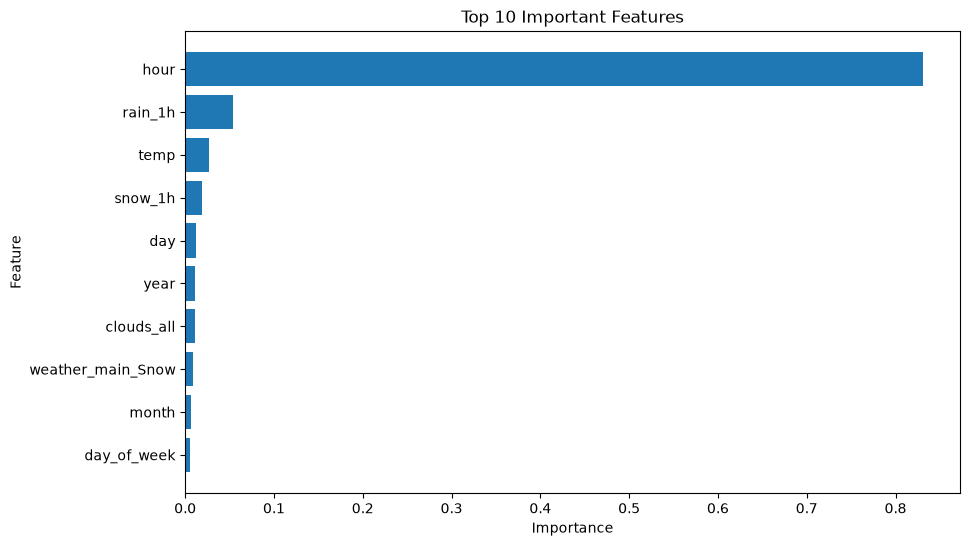

In [146]:
plt.figure(figsize=(10,6))

plt.barh(feature_importance["Feature"].head(10),feature_importance["Importance"].head(10))

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [147]:
import joblib
joblib.dump(model_rf, "traffic_model.pkl")

['traffic_model.pkl']

In [148]:
joblib.dump(list(X.columns),"model_features.pkl")

['model_features.pkl']